# Sesión 4 — Matriz de rigidez no lineal y algoritmos de solución

## Caso `mi_primer_analisis`

Se transforma la rigidez seccional $EI_{sec}(P)$ de la sesión 3 en la matriz del elemento de pórtico 2D. También se comparan control por carga, control por desplazamiento y longitud de arco en un problema pedagógico de un grado de libertad.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

def buscar_raiz(inicio=None):
    inicio = Path.cwd() if inicio is None else Path(inicio)
    for carpeta in (inicio, *inicio.parents):
        if (carpeta / "temario.md").is_file() and (carpeta / "PUSHOVER_PORTABLE").is_dir():
            return carpeta
    raise FileNotFoundError(
        "No se encontró la raíz del curso. En Colab, clona o monta primero el repositorio."
    )

RAIZ = buscar_raiz()
PORTABLE = RAIZ / "PUSHOVER_PORTABLE"
if str(PORTABLE) in sys.path:
    sys.path.remove(str(PORTABLE))
sys.path.insert(0, str(PORTABLE))

RUTA_MAESTRA = PORTABLE / "casos" / "mi_primer_analisis" / "entrada_maestra.json"
RUTA_GEOMETRIA = PORTABLE / "casos" / "mi_primer_analisis" / "geometria_secciones.json"
CASO_ID = "mi_primer_analisis"

from ejecutar_pushover import cargar_entrada_maestra
from sesion_03.biblioteca_rotulas import leer_contrato_sesion03
from sesion_04.rigidez_portico import (
    matriz_rigidez_local_portico2d, matriz_transformacion_portico2d,
    rigidez_elemento_portico2d,
)
from sesion_04.solvers_no_lineales import (
    fuerza_normalizada, newton_control_carga, control_desplazamiento,
    longitud_arco_1gdl, extraer_historia,
)
from sesion_06.rotulas_axiales import interpolar_ley_axial

entrada, _, _ = cargar_entrada_maestra(RUTA_MAESTRA)
RUTA_C03 = RAIZ / "sesion_03" / "resultados_mi_primer_analisis" / "contrato_sesion03.json"
c03 = leer_contrato_sesion03(RUTA_C03)
biblioteca = c03["biblioteca_rotulas"]
print("Contrato S3:", RUTA_C03.relative_to(RAIZ), "| schema", c03["schema_version"])

Contrato S3: sesion_03\resultados_mi_primer_analisis\contrato_sesion03.json | schema 3.5


## 1. Matriz local del elemento 2D

Con los GDL locales $[u_i,v_i,\theta_i,u_j,v_j,\theta_j]^T$, la matriz contiene los términos $EA/L$, $12EI/L^3$, $6EI/L^2$, $4EI/L$ y $2EI/L$. Antes de restringir apoyos debe ser simétrica y tener tres modos de cuerpo rígido.

In [2]:
P0 = float(entrada["modelo"]["P_referencia_inicial_kgf"])
L = float(entrada["edificio"]["altura_entrepiso_cm"])
verificaciones = {}
for sid, sec in entrada["secciones"].items():
    estado = interpolar_ley_axial(biblioteca[sid]["positivo"], P0, fuera_de_rango="limitar")
    EI = float(estado["EI_sec_kgf_cm2"])
    Ec = float(sec.get("Ec_kgf_cm2", entrada["modelo"]["Ec_coef_sqrt_fc"] * np.sqrt(sec["fc_kgf_cm2"])))
    EA = Ec * float(sec["b_cm"]) * float(sec["h_cm"])
    k = matriz_rigidez_local_portico2d(EA, EI, L)
    eig = np.linalg.eigvalsh(k)
    tol = 1e-5 * eig.max()
    assert np.allclose(k, k.T)
    assert np.count_nonzero(np.abs(eig) < tol) == 3
    positivos = eig[eig > tol]
    verificaciones[sid] = {
        "P_referencia_kgf": P0, "EA_kgf": EA, "EI_kgf_cm2": EI,
        "L_referencia_cm": L, "matriz_simetrica": True,
        "autovalor_minimo_no_nulo": float(positivos.min()),
    }
    print(sid, f"EA={EA:.4e} kgf", f"EI={EI:.4e} kgf·cm²", "modos rígidos=3")

C1 EA=1.9563e+08 kgf EI=3.7667e+09 kgf·cm² modos rígidos=3
V1 EA=1.9563e+08 kgf EI=3.9409e+09 kgf·cm² modos rígidos=3


## 2. Transformación y degradación de rigidez

En coordenadas globales, $K_g=T^TK_lT$. El factor $\eta$ se usa aquí para visualizar el efecto de una reducción de $EI$; en el pushover la pérdida tangente aparecerá por activación y condensación de las rótulas.

In [3]:
sid = "C1"
sec = entrada["secciones"][sid]
estado = interpolar_ley_axial(biblioteca[sid]["positivo"], P0, fuera_de_rango="limitar")
Ec = entrada["modelo"]["Ec_coef_sqrt_fc"] * np.sqrt(sec["fc_kgf_cm2"])
EA = Ec * sec["b_cm"] * sec["h_cm"]
EI = estado["EI_sec_kgf_cm2"]
angulo = np.deg2rad(30)
T = matriz_transformacion_portico2d(angulo)
normas = {}
for eta in (1.0, 0.5, 0.2):
    res = rigidez_elemento_portico2d(EA, EI, L, angulo_rad=angulo, eta=eta)
    normas[eta] = np.linalg.norm(res["global"], 2)
    print(f"η={eta:.1f}: ||Kg||₂={normas[eta]:.4e}")
assert np.allclose(T @ T.T, np.eye(6))
assert normas[0.2] <= normas[0.5] <= normas[1.0]

η=1.0: ||Kg||₂=5.6501e+07
η=0.5: ||Kg||₂=2.8251e+07
η=0.2: ||Kg||₂=1.1300e+07


## 3. Estrategias de continuación

El control por carga prescribe $\lambda$ y puede fallar cerca de una tangente nula. El control por desplazamiento prescribe la respuesta y resuelve el factor de carga compatible. La longitud de arco agrega una restricción geométrica; no debe confundirse con el control directo usado en la sesión 6.

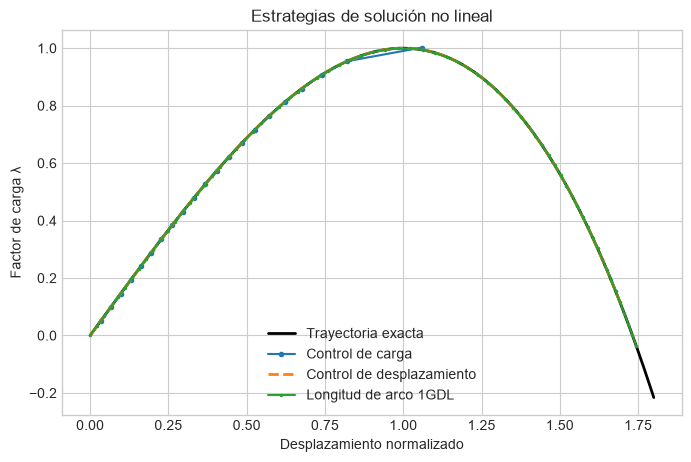

In [4]:
h_carga = newton_control_carga(np.linspace(0.05, 1.05, 22))
h_despl = control_desplazamiento(np.linspace(0, 1.7, 70))
h_arco = longitud_arco_1gdl(n_pasos=70, ds=0.04)
xc, lc = extraer_historia(h_carga)
xd, ld = extraer_historia(h_despl)
xa, la = extraer_historia(h_arco)
xx = np.linspace(0, 1.8, 300)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xx, fuerza_normalizada(xx), color="black", lw=2, label="Trayectoria exacta")
ax.plot(xc, lc, "o-", ms=3, label="Control de carga")
ax.plot(xd, ld, "--", lw=2, label="Control de desplazamiento")
ax.plot(xa, la, ".-", ms=3, label="Longitud de arco 1GDL")
ax.set(xlabel="Desplazamiento normalizado", ylabel="Factor de carga λ",
       title="Estrategias de solución no lineal")
ax.legend(); plt.show()

## 4. Contrato de la sesión 4

In [5]:
contrato_s4 = {
    "schema_version": "2.3", "sesion_origen": "sesion_04",
    "caso_id": CASO_ID, "verificaciones": verificaciones,
}
SALIDA = RAIZ / "sesion_04" / "resultados_mi_primer_analisis"
SALIDA.mkdir(parents=True, exist_ok=True)
RUTA_C04 = SALIDA / "contrato_sesion04.json"
RUTA_C04.write_text(json.dumps(contrato_s4, ensure_ascii=False, indent=2), encoding="utf-8")
print("Contrato guardado:", RUTA_C04.relative_to(RAIZ))

Contrato guardado: sesion_04\resultados_mi_primer_analisis\contrato_sesion04.json


## 5. Cierre

La sesión 3 proporcionó rigidez y resistencia de las secciones. Esta sesión verificó cómo entran en la matriz y cómo cambia el equilibrio al degradarse la rigidez. La sesión 5 ensamblará el pórtico completo.